# Part 2: Audio → Mel-Spectrogram (.pt) + MFCC features (.npy)
แปลงไฟล์เสียงเป็น:
- `mel/*.pt` → ใช้กับ 2D CNN
- `mfcc/*.npy` → ใช้กับ Random Forest (Part 3 baseline)

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR     = '/content/drive/MyDrive/music-genre'
DATA_DIR     = f'{BASE_DIR}/data'
PROCESSED_DIR = f'{DATA_DIR}/processed'
AUDIO_DIR    = f'{DATA_DIR}/fma_small'
MEL_DIR      = f'{PROCESSED_DIR}/mel'
MFCC_DIR     = f'{PROCESSED_DIR}/mfcc'

import os
os.makedirs(MEL_DIR,  exist_ok=True)
os.makedirs(MFCC_DIR, exist_ok=True)
print('Dirs ready.')

Mounted at /content/drive
Dirs ready.


In [ ]:
# Install dependencies
!pip install -q torchaudio librosa

In [ ]:
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ==================== CONFIG ====================
SAMPLE_RATE  = 22050   # Hz
DURATION     = 30      # วินาที (FMA แต่ละเพลง 30s)
N_MELS       = 128     # จำนวน mel filterbank
N_FFT        = 2048    # FFT window size
HOP_LENGTH   = 512     # hop size
N_MFCC       = 40      # จำนวน MFCC coefficients สำหรับ Random Forest
# ================================================

NUM_SAMPLES  = SAMPLE_RATE * DURATION  # 661500 samples

# Mel-Spectrogram transform
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
)
amplitude_to_db = T.AmplitudeToDB(top_db=80)

# MFCC transform
mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={'n_fft': N_FFT, 'hop_length': HOP_LENGTH, 'n_mels': N_MELS},
)

print('Transforms ready.')
print(f'Expected mel shape: (1, {N_MELS}, {NUM_SAMPLES // HOP_LENGTH + 1})')

Transforms ready.
Expected mel shape: (1, 128, 1292)


In [ ]:
def load_audio(path: str) -> torch.Tensor | None:
    """โหลด audio และ normalize ให้ได้ mono 22050Hz ยาว 30 วินาทีพอดี"""
    try:
        waveform, sr = torchaudio.load(path)
    except Exception:
        return None

    # แปลงเป็น mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample ถ้า sample rate ไม่ตรง
    if sr != SAMPLE_RATE:
        waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

    # Pad หรือ Trim ให้ได้ NUM_SAMPLES พอดี
    if waveform.shape[1] < NUM_SAMPLES:
        pad = NUM_SAMPLES - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, pad))
    else:
        waveform = waveform[:, :NUM_SAMPLES]

    return waveform


def process_track(audio_path: str, track_id: int) -> bool:
    """แปลง 1 track → mel .pt และ mfcc .npy"""
    mel_path  = Path(MEL_DIR)  / f'{track_id}.pt'
    mfcc_path = Path(MFCC_DIR) / f'{track_id}.npy'

    # ข้ามถ้าทำไปแล้ว
    if mel_path.exists() and mfcc_path.exists():
        return True

    waveform = load_audio(audio_path)
    if waveform is None:
        return False

    # Mel-Spectrogram → .pt
    mel = mel_transform(waveform)       # (1, N_MELS, T)
    mel = amplitude_to_db(mel)          # แปลงเป็น dB scale
    torch.save(mel, mel_path)

    # MFCC → .npy (เอา mean+std across time เป็น feature vector)
    mfcc = mfcc_transform(waveform)     # (1, N_MFCC, T)
    mfcc = mfcc.squeeze(0).numpy()      # (N_MFCC, T)
    feature = np.concatenate([
        mfcc.mean(axis=1),              # mean ของแต่ละ coefficient
        mfcc.std(axis=1),               # std ของแต่ละ coefficient
    ])                                  # shape: (N_MFCC*2,) = (80,)
    np.save(mfcc_path, feature)

    return True

print('Functions ready.')

Functions ready.


In [ ]:
# โหลด CSV ทั้งหมด
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Total tracks to process: {len(all_df)}')

Total tracks to process: 8000


In [ ]:
# Process ทุก track
failed = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df), desc='Processing'):
    success = process_track(row['audio_path'], row['track_id'])
    if not success:
        failed.append(row['track_id'])

print(f'\n✅ Done! Failed: {len(failed)} tracks')
if failed:
    print('Failed track IDs:', failed[:10])

Processing: 100%|██████████| 8000/8000 [1:27:01<00:00,  1.53it/s]


✅ Done! Failed: 6 tracks
Failed track IDs: [108925, 98569, 98567, 133297, 98565, 99134]


In [ ]:
# ตรวจสอบผลลัพธ์
mel_files  = list(Path(MEL_DIR).glob('*.pt'))
mfcc_files = list(Path(MFCC_DIR).glob('*.npy'))
print(f'Mel files (.pt):   {len(mel_files)}')
print(f'MFCC files (.npy): {len(mfcc_files)}')

# ดู shape ตัวอย่าง
sample_mel  = torch.load(mel_files[0])
sample_mfcc = np.load(str(mfcc_files[0]))
print(f'\nSample mel shape:  {sample_mel.shape}   ← input สำหรับ 2D CNN')
print(f'Sample mfcc shape: {sample_mfcc.shape}  ← input สำหรับ Random Forest')

Mel files (.pt):   7994
MFCC files (.npy): 7994

Sample mel shape:  torch.Size([1, 128, 1292])   ← input สำหรับ 2D CNN
Sample mfcc shape: (80,)  ← input สำหรับ Random Forest


/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10288/20406401.py:20: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.

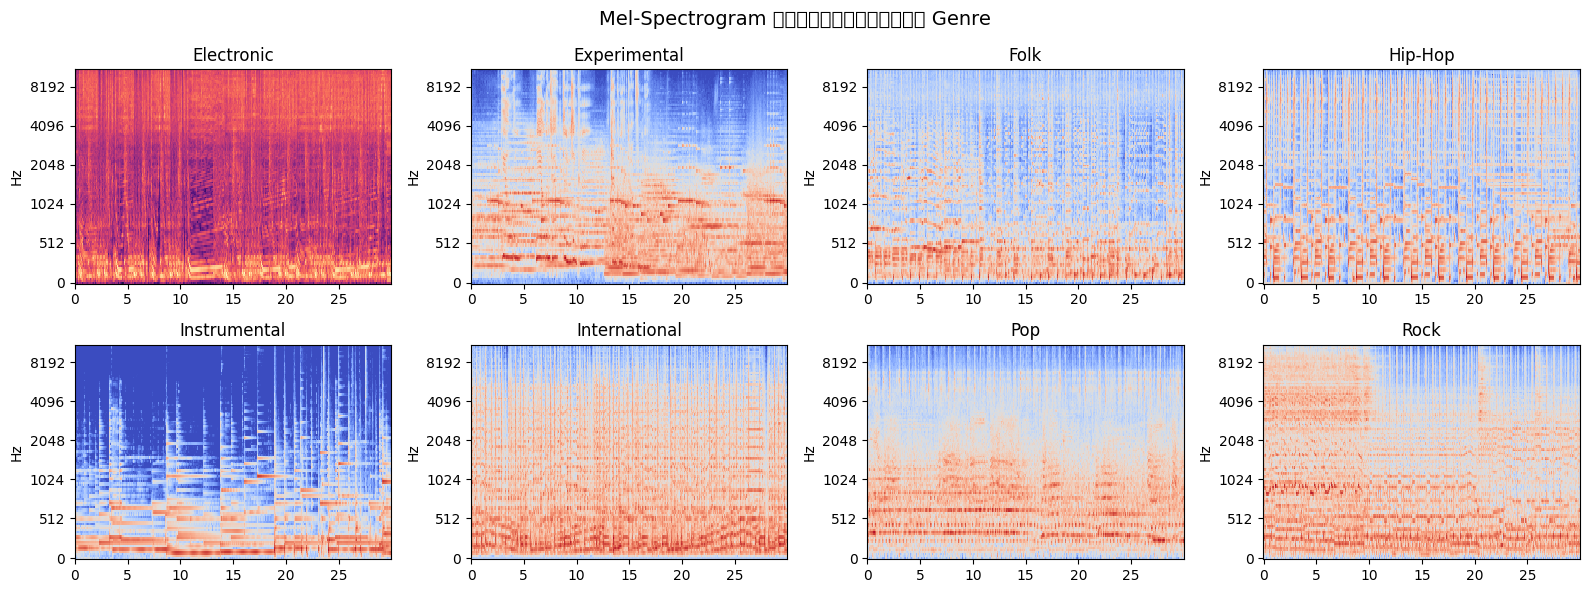

Saved mel_samples.png


In [ ]:
# Visualize ตัวอย่าง Mel-Spectrogram
import matplotlib.pyplot as plt
import librosa.display

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
label_map = pd.read_csv(f'{PROCESSED_DIR}/label_map.csv')
idx2genre = dict(zip(label_map['label'], label_map['genre']))

for ax, (_, row) in zip(axes.flat, all_df.groupby('genre').first().iterrows()):
    mel_path = Path(MEL_DIR) / f'{row["track_id"]}.pt'
    if not mel_path.exists():
        continue
    mel = torch.load(mel_path).squeeze(0).numpy()
    librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(row.name)
    ax.set_xlabel('')

plt.suptitle('Mel-Spectrogram ตัวอย่างแต่ละ Genre', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/mel_samples.png', dpi=100)
plt.show()
print('Saved mel_samples.png')